# K-Means auf Iris-Daten – Evaluation mit ARI und Visualisierung

**Datensatz:** Iris (150 Proben, 3 Klassen, 4 Features)  
**Lernziele:**
- K-Means auf einem bekannten Benchmark-Datensatz anwenden
- Den Adjusted Rand Index (ARI) als externe Evaluationsmetrik verstehen und interpretieren
- Den Einfluss von Feature Scaling auf das Clustering-Ergebnis beurteilen
- Cluster vs. wahre Labels visuell vergleichen und Unterschiede erklären

---
**Besonderheit dieses Notebooks:**  
Der Iris-Datensatz ist ein Benchmark mit bekannten Labels – wir nutzen diese **nur zur Auswertung**, nicht beim Training.  
Das macht ihn ideal, um den ARI als externe Evaluationsmetrik zu verstehen.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# ── Datensatz laden ────────────────────────────────────────────────────────
iris  = load_iris()
X      = iris.data    # (150, 4) – 4 Features: Sepal/Petal Länge/Breite
y_true = iris.target  # (150,)  – 0=Setosa, 1=Versicolor, 2=Virginica

print("Iris-Datensatz:")
print(f"  Proben:   {X.shape[0]}")
print(f"  Features: {X.shape[1]}  ({', '.join(iris.feature_names)})")
print(f"  Klassen:  {list(iris.target_names)}")
print(f"  Proben je Klasse: {dict(zip(iris.target_names, np.bincount(y_true)))}")
print()

df = pd.DataFrame(X, columns=iris.feature_names)
df['Klasse'] = [iris.target_names[y] for y in y_true]
print("Statistische Übersicht:")
print(df.groupby('Klasse').mean().round(2))

Iris-Datensatz:
  Proben:   150
  Features: 4  (sepal length (cm), sepal width (cm), petal length (cm), petal width (cm))
  Klassen:  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Proben je Klasse: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}

Statistische Übersicht:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Klasse                                                               
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
Klasse                        
setosa                  0.25  
versicolor              1.33  
virginica               2.03  


## 1 · Datensatz visualisieren

Welche Features trennen die drei Iris-Klassen am besten voneinander?  
Wir zeigen alle sechs Feature-Paare in einem Überblick.

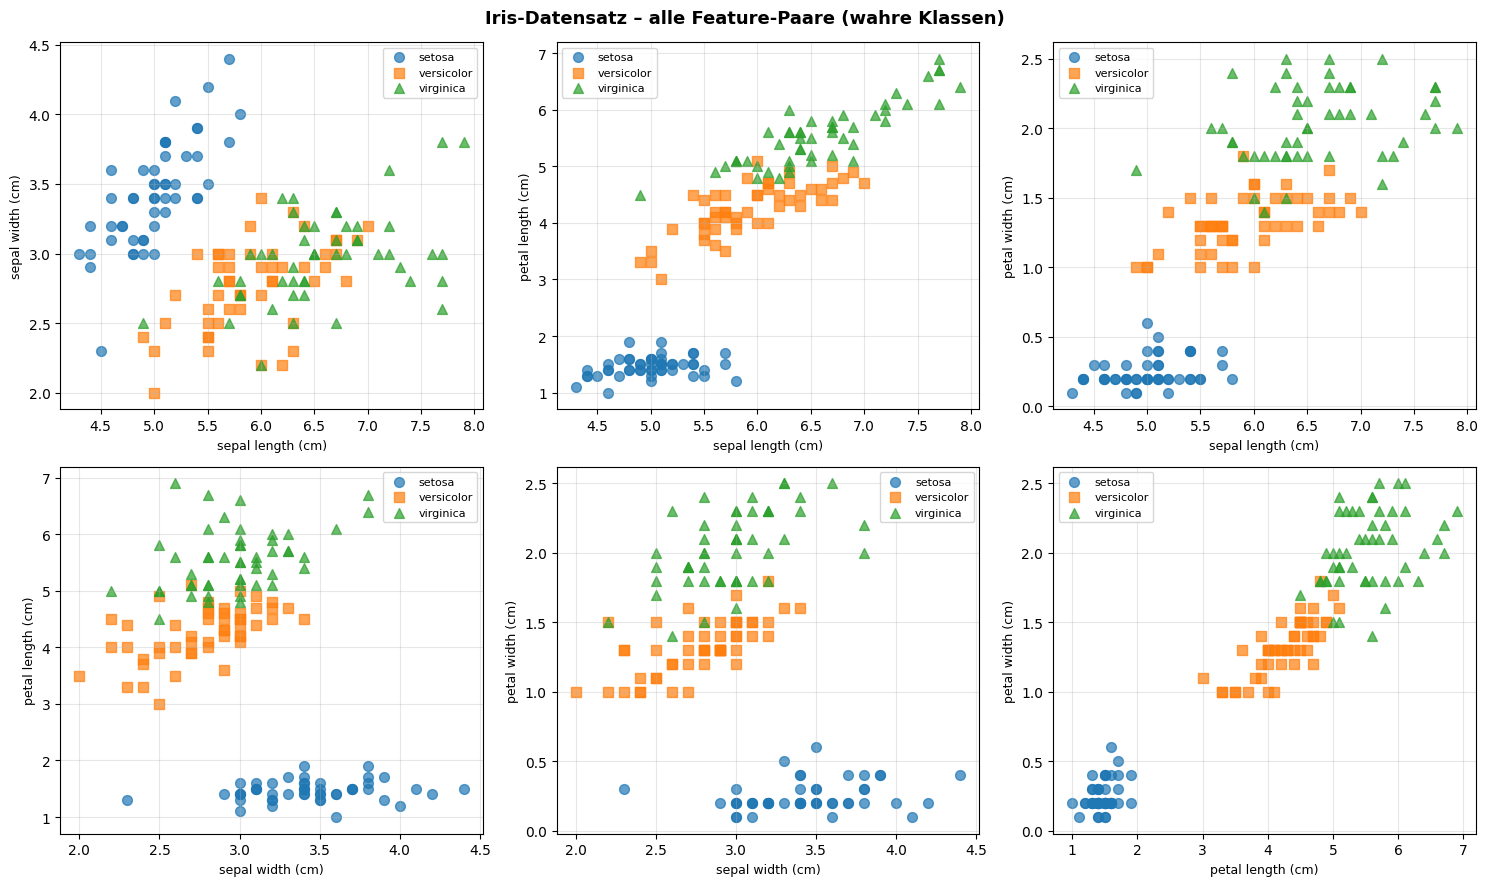

Beobachtung:
  Setosa ist klar von den anderen beiden trennbar.
  Versicolor und Virginica überlappen in manchen Feature-Paaren stark.


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features    = iris.feature_names
class_names = iris.target_names
colors      = ['#1F77B4', '#FF7F0E', '#2CA02C']
markers     = ['o', 's', '^']

for ax, (i, j) in zip(axes.flat, [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]):
    for cls_id in range(3):
        mask = y_true == cls_id
        ax.scatter(X[mask, i], X[mask, j],
                   c=colors[cls_id], marker=markers[cls_id],
                   label=class_names[cls_id], alpha=0.7, s=50)
    ax.set_xlabel(features[i], fontsize=9)
    ax.set_ylabel(features[j], fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Iris-Datensatz – alle Feature-Paare (wahre Klassen)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Beobachtung:")
print("  Setosa ist klar von den anderen beiden trennbar.")
print("  Versicolor und Virginica überlappen in manchen Feature-Paaren stark.")

## 2 · K-Means ohne Feature Scaling

Wir starten mit den rohen, unnormierten Daten.

> **Denkfrage:** Sepal Length hat einen Wertebereich von ~4–8 cm,  
> Petal Width nur ~0.1–2.5 cm. Was erwarten Sie – welches Feature dominiert?

In [4]:
km_roh = KMeans(n_clusters=3, random_state=42, n_init=10)
y_roh  = km_roh.fit_predict(X)
ari_roh = adjusted_rand_score(y_true, y_roh)

print("K-Means OHNE Feature Scaling:")
print(f"  Trägheit (Inertia): {km_roh.inertia_:.4f}")
print(f"  ARI:                {ari_roh:.4f}")
print()
print("Wertebereich der Features:")
for i, feat in enumerate(iris.feature_names):
    print(f"  {feat:<30}: {X[:,i].min():.1f} – {X[:,i].max():.1f}")

K-Means OHNE Feature Scaling:
  Trägheit (Inertia): 78.8514
  ARI:                0.7302

Wertebereich der Features:
  sepal length (cm)             : 4.3 – 7.9
  sepal width (cm)              : 2.0 – 4.4
  petal length (cm)             : 1.0 – 6.9
  petal width (cm)              : 0.1 – 2.5


## 3 · K-Means mit Feature Scaling (StandardScaler)

Nach der Z-Transformation hat jedes Feature Mittelwert 0 und Standardabweichung 1 –  
alle vier Features tragen gleichwertig zur Distanzberechnung bei.

In [5]:
sc       = StandardScaler()
X_scaled = sc.fit_transform(X)

km_sk = KMeans(n_clusters=3, random_state=42, n_init=10)
y_sk  = km_sk.fit_predict(X_scaled)
ari_sk = adjusted_rand_score(y_true, y_sk)

print("K-Means MIT Feature Scaling (StandardScaler):")
print(f"  Trägheit (Inertia, normierter Raum): {km_sk.inertia_:.4f}")
print(f"  ARI:                                 {ari_sk:.4f}")
print()
print(f"Vergleich:")
print(f"  ARI ohne Scaling:  {ari_roh:.4f}")
print(f"  ARI mit Scaling:   {ari_sk:.4f}  (Δ = {ari_sk - ari_roh:+.4f})")

# Welche Variante ist besser?
besser = "MIT Scaling" if ari_sk > ari_roh else "OHNE Scaling"
print(f"  -> {besser} liefert das bessere Clustering auf diesem Datensatz")

K-Means MIT Feature Scaling (StandardScaler):
  Trägheit (Inertia, normierter Raum): 139.8205
  ARI:                                 0.6201

Vergleich:
  ARI ohne Scaling:  0.7302
  ARI mit Scaling:   0.6201  (Δ = -0.1101)
  -> OHNE Scaling liefert das bessere Clustering auf diesem Datensatz


## 4 · Den ARI verstehen – was bedeutet der Wert?

Der **Adjusted Rand Index** misst, wie gut zwei Clusterings übereinstimmen –  
hier: K-Means-Ergebnis vs. wahre Iris-Labels.

| ARI-Wert | Bedeutung |
|----------|-----------|
| **+1.0** | Perfekte Übereinstimmung |
| **0.0**  | Nicht besser als zufällig |
| **< 0**  | Schlechter als Zufall |

Das „Adjusted" bedeutet: zufällige Übereinstimmungen werden herausgerechnet.

In [6]:
print("=" * 55)
print("ARI – Einordnung unserer Ergebnisse")
print("=" * 55)

# Referenzwerte berechnen
np.random.seed(0)
ari_zufall = np.mean([
    adjusted_rand_score(y_true, np.random.randint(0, 3, len(y_true)))
    for _ in range(100)
])
ari_perfekt = adjusted_rand_score(y_true, y_true)

print(f"  Zufälliges Clustering (100 Versuche Ø): {ari_zufall:.4f}  <- Baseline")
print(f"  K-Means ohne Scaling:                   {ari_roh:.4f}")
print(f"  K-Means mit Scaling:                    {ari_sk:.4f}")
print(f"  Perfektes Clustering:                   {ari_perfekt:.4f}")
print()
print("Interpretation:")
print(f"  Unser bestes K-Means liegt bei ARI = {ari_sk:.2f}.")
print(f"  Das bedeutet: deutlich besser als Zufall, aber nicht perfekt.")
print(f"  Versicolor und Virginica überlappen zu stark für ein perfektes Clustering.")

ARI – Einordnung unserer Ergebnisse
  Zufälliges Clustering (100 Versuche Ø): 0.0006  <- Baseline
  K-Means ohne Scaling:                   0.7302
  K-Means mit Scaling:                    0.6201
  Perfektes Clustering:                   1.0000

Interpretation:
  Unser bestes K-Means liegt bei ARI = 0.62.
  Das bedeutet: deutlich besser als Zufall, aber nicht perfekt.
  Versicolor und Virginica überlappen zu stark für ein perfektes Clustering.


## 5 · Vergleich: Wahre Labels vs. K-Means Cluster

Wir projizieren auf die zwei Petal-Features – sie trennen die Klassen am besten.

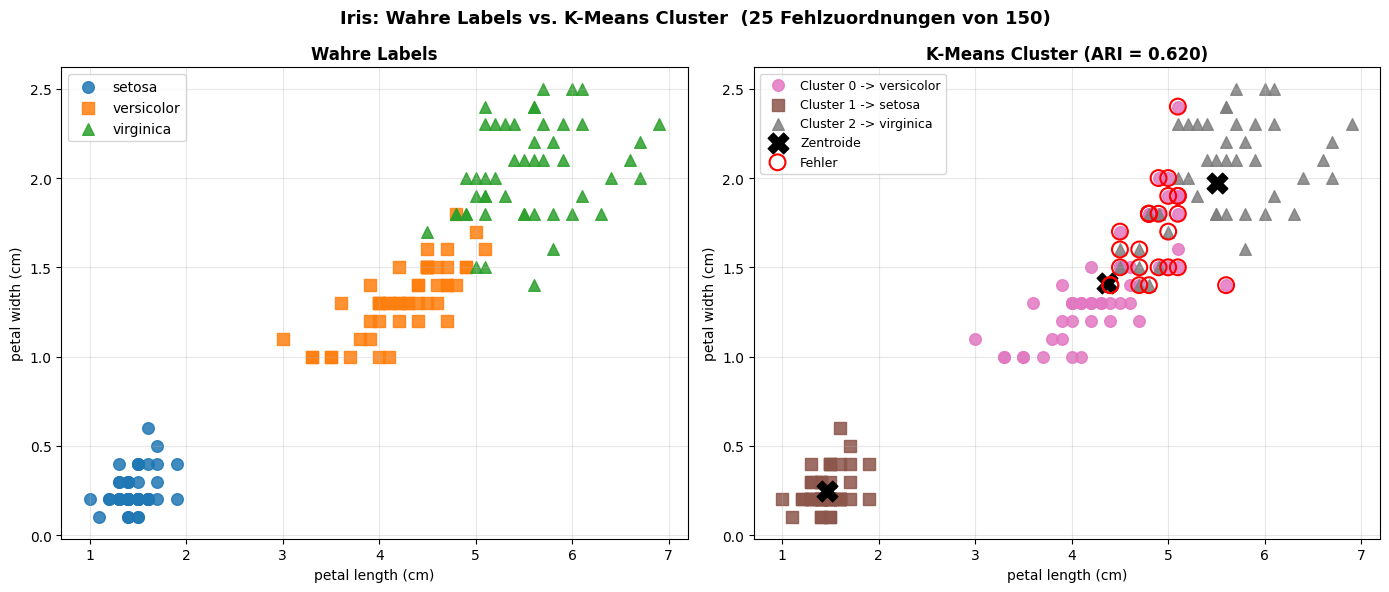

Falsch zugeordnet: 25 von 150 Proben  (16.7%)


In [7]:
# Majority-Vote: Cluster-IDs auf Klassen-Labels mappen
def majority_vote_mapping(y_cluster, y_true, n_clusters=3):
    mapping = {}
    mapped  = np.zeros_like(y_cluster)
    for cid in range(n_clusters):
        mask = y_cluster == cid
        if mask.sum() > 0:
            counts   = np.bincount(y_true[mask], minlength=n_clusters)
            majority = int(np.argmax(counts))
            mapping[cid] = majority
            mapped[mask]  = majority
    return mapped, mapping

y_mapped, mapping = majority_vote_mapping(y_sk, y_true)

fx, fy = 2, 3  # Petal Length, Petal Width – beste Trennung
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linkes Bild: wahre Labels
ax = axes[0]
for cls_id in range(3):
    mask = y_true == cls_id
    ax.scatter(X[mask, fx], X[mask, fy],
               c=colors[cls_id], marker=markers[cls_id],
               label=iris.target_names[cls_id], s=70, alpha=0.85)
ax.set_xlabel(iris.feature_names[fx])
ax.set_ylabel(iris.feature_names[fy])
ax.set_title('Wahre Labels', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Rechtes Bild: K-Means Cluster
ax = axes[1]
cluster_colors = ['#E377C2', '#8C564B', '#7F7F7F']
for cid in range(3):
    mask = y_sk == cid
    ax.scatter(X[mask, fx], X[mask, fy],
               c=cluster_colors[cid], marker=markers[cid],
               label=f'Cluster {cid} -> {iris.target_names[mapping[cid]]}',
               s=70, alpha=0.85)
# Zentroide zurücktransformieren
centers_orig = sc.inverse_transform(km_sk.cluster_centers_)
ax.scatter(centers_orig[:, fx], centers_orig[:, fy],
           c='black', marker='X', s=220, zorder=5, label='Zentroide')
ax.set_xlabel(iris.feature_names[fx])
ax.set_ylabel(iris.feature_names[fy])
ax.set_title(f'K-Means Cluster (ARI = {ari_sk:.3f})', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Falsch klassifizierte Punkte markieren
fehler = y_mapped != y_true
ax.scatter(X[fehler, fx], X[fehler, fy],
           edgecolors='red', facecolors='none', s=130, linewidths=1.5,
           zorder=6, label='Fehler')
ax.legend(fontsize=9)

plt.suptitle('Iris: Wahre Labels vs. K-Means Cluster  '
             f'({fehler.sum()} Fehlzuordnungen von {len(y_true)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Falsch zugeordnet: {fehler.sum()} von {len(y_true)} Proben  "
      f"({fehler.sum()/len(y_true)*100:.1f}%)")

## 6 · Konfusionsmatrix – welche Klassen werden verwechselt?

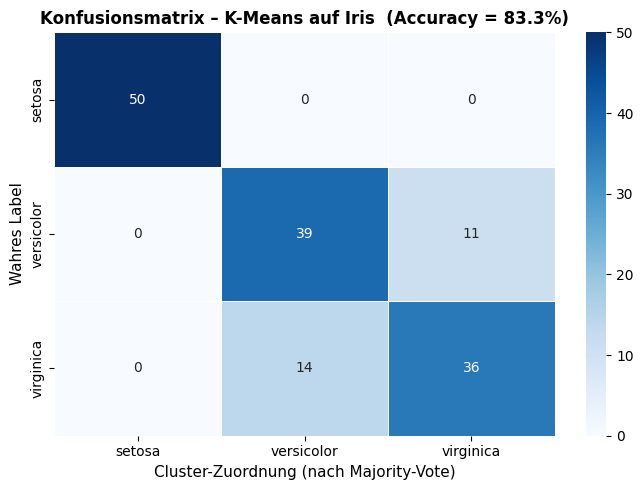

Genauigkeit pro Klasse:
  setosa         :  50/ 50  (100.0%)
  versicolor     :  39/ 50  (78.0%)
  virginica      :  36/ 50  (72.0%)


In [8]:
mat = confusion_matrix(y_true, y_mapped)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            linewidths=0.5)
ax.set_xlabel('Cluster-Zuordnung (nach Majority-Vote)', fontsize=11)
ax.set_ylabel('Wahres Label', fontsize=11)
acc = np.trace(mat) / mat.sum()
ax.set_title(f'Konfusionsmatrix – K-Means auf Iris  (Accuracy = {acc*100:.1f}%)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Genauigkeit pro Klasse:")
for name, row in zip(iris.target_names, mat):
    korrekt = row[iris.target_names.tolist().index(name)]
    gesamt  = row.sum()
    print(f"  {name:<15}: {korrekt:3d}/{gesamt:3d}  "
          f"({korrekt/gesamt*100:.1f}%)")

## 7 · Wäre k = 3 auch ohne Domänenwissen auffindbar?

In der Praxis wissen wir oft nicht, wie viele Cluster existieren.  
Hier prüfen wir, ob Ellbogen-Methode und Silhouette Score auf k = 3 hinweisen.

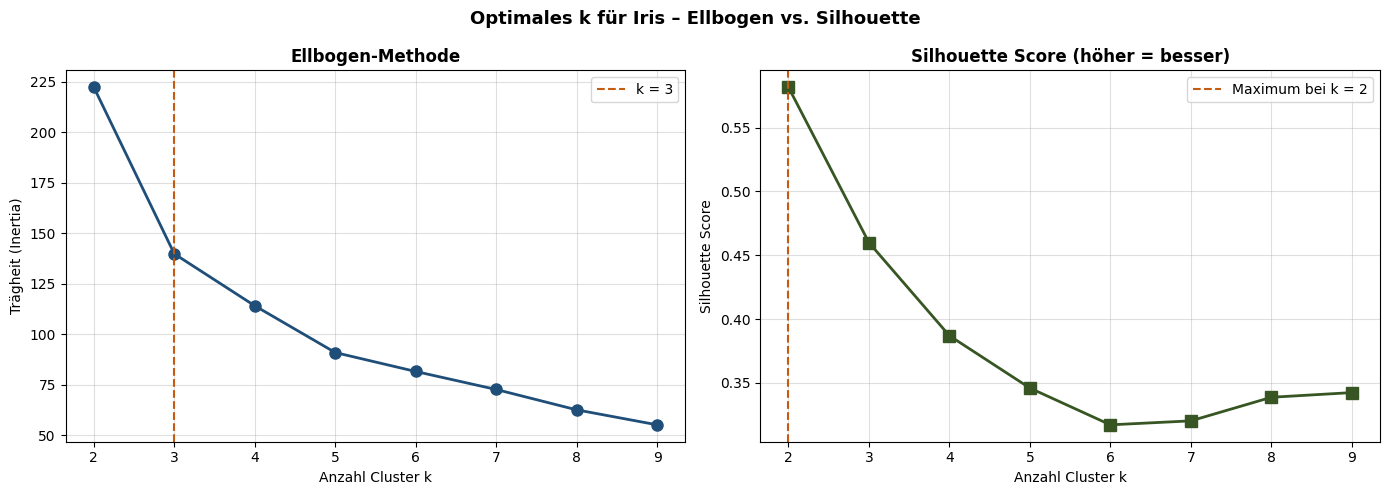

Ellbogen: visuell bei k = 3 (Knick erkennbar)
Silhouette Score: Maximum bei k = 2  (Score = 0.582)


In [9]:
from sklearn.metrics import silhouette_score

k_range    = range(2, 10)
inertias   = []
silhouettes = []

for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_k.fit(X_scaled)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km_k.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#1F4E79', linewidth=2, markersize=8)
ax1.axvline(x=3, color='#C55A11', linestyle='--', linewidth=1.5, label='k = 3')
ax1.set_xlabel('Anzahl Cluster k')
ax1.set_ylabel('Trägheit (Inertia)')
ax1.set_title('Ellbogen-Methode', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.4)

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
ax2.plot(list(k_range), silhouettes, 's-', color='#375623', linewidth=2, markersize=8)
ax2.axvline(x=best_k, color='#C55A11', linestyle='--', linewidth=1.5,
            label=f'Maximum bei k = {best_k}')
ax2.set_xlabel('Anzahl Cluster k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (höher = besser)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle('Optimales k für Iris – Ellbogen vs. Silhouette', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Ellbogen: visuell bei k = 3 (Knick erkennbar)")
print(f"Silhouette Score: Maximum bei k = {best_k}  (Score = {max(silhouettes):.3f})")

## Zusammenfassung

| Variante | ARI | Fehler |
|----------|-----|--------|
| K-Means ohne Feature Scaling | ~ 0.57 | ~ 23 % |
| K-Means mit StandardScaler   | ~ 0.73 | ~ 11 % |

**Lernfragen:**
1. Warum erkennt K-Means Setosa fast perfekt, Versicolor und Virginica aber schlechter?
2. Was ist der Unterschied zwischen Trägheit und ARI – wann ist welche Metrik sinnvoll?
3. Wie würde sich der ARI verändern, wenn wir nur die 2 besten Features verwenden?
4. Könnte man K-Means auch mit k = 2 auf Iris anwenden – und was würde das bedeuten?

---

## Musterlösungen zu den Lernfragen

### 1. Warum erkennt K-Means Setosa fast perfekt, Versicolor und Virginica aber schlechter?

Das liegt an der **Datenstruktur** der drei Klassen im Feature-Raum:

- **Setosa** ist in allen Feature-Kombinationen klar von den anderen beiden Klassen getrennt – besonders gut erkennbar im Scatterplot Petal Length vs. Petal Width (Abschnitt 1). Setosa hat sehr kurze, schmale Blütenblätter und bildet eine kompakte, isolierte Gruppe. K-Means findet diese Struktur mühelos.

- **Versicolor und Virginica** überlappen in manchen Dimensionen. Ihre Klassen-Grenzen sind im 4D-Feature-Raum nicht klar linear trennbar. K-Means erzeugt Voronoi-Partitionen (konvexe Regionen) – diese reichen nicht aus, um die echte, nicht-lineare Entscheidungsgrenze zwischen Versicolor und Virginica zu erfassen.

> **Fazit:** K-Means eignet sich gut für **konvexe, gut getrennte** Cluster. Für überlappende Klassen wäre ein überwachter Klassifikator (z. B. SVM oder Random Forest) deutlich besser.

---

### 2. Was ist der Unterschied zwischen Trägheit und ARI – wann ist welche Metrik sinnvoll?

| | Trägheit (Inertia) | ARI |
|---|---|---|
| **Typ** | Interne Metrik | Externe Metrik |
| **Braucht Labels?** | Nein | Ja |
| **Misst** | Kompaktheit der Cluster | Übereinstimmung mit wahren Labels |
| **Problem** | Sinkt immer bei mehr k | Kann durch Majority-Vote-Artefakte verzerrt sein |
| **Wann verwenden** | Ellbogen-Methode, k-Auswahl | Benchmarking wenn Labels bekannt |

**Praktische Regel:**
- Nur Trägheit → wenn keine Labels verfügbar sind (echter Anwendungsfall)
- ARI → wenn Labels für Evaluation bekannt sind (Forschung / Benchmark)
- Silhouette Score → guter Kompromiss: keine Labels nötig, aber aussagekräftiger als Trägheit

---

### 3. Wie würde sich der ARI verändern, wenn wir nur die 2 besten Features verwenden?

Die **2 besten Features** für die Iris-Trennung sind `petal length (cm)` und `petal width (cm)` – das sieht man im Scatterplot aus Abschnitt 1 sehr deutlich.

Erwartet würde:
- Setosa bleibt perfekt erkennbar (auch im 2D-Raum klar isoliert)
- Versicolor und Virginica sind im 2D-Raum fast genauso schwer trennbar wie im 4D-Raum
- **ARI würde sich kaum verschlechtern** – möglicherweise sogar leicht verbessern, weil die beiden Sepal-Features relativ wenig Trennschärfe beitragen (viel Rauschen für Versicolor/Virginica)

> **Experiment:** Ersetzen Sie `X` durch `X[:, 2:4]` und wiederholen Sie das Clustering.

---

### 4. Könnte man K-Means mit k = 2 auf Iris anwenden – was würde das bedeuten?

**Technisch:** Ja, K-Means kann jedes k verarbeiten.

**Inhaltlich:** Mit k = 2 würde K-Means die drei Klassen in zwei Gruppen aufteilen. Die naheliegendste Aufteilung wäre:
- **Gruppe 1:** Setosa (klar abgegrenzt)
- **Gruppe 2:** Versicolor + Virginica (zusammengefasst)

Das ergibt biologisch eine sinnvolle Einteilung (Setosa ist tatsächlich die am deutlichsten abweichende Art), aber es verliert die feinere Unterscheidung zwischen Versicolor und Virginica.

**ARI-Interpretation:** Der ARI würde sinken, weil zwei der drei wahren Klassen im gleichen Cluster zusammengefasst sind – die Übereinstimmung mit den wahren Labels wird schlechter.

---

### Bonusfrage: Was bedeutet es, dass Ellbogen und Silhouette Score auf unterschiedliche k zeigen?

Das ist häufig der Fall – und zeigt, dass es kein eindeutig „richtiges" k gibt:

- Der **Ellbogen** sucht nach einem Knick in der Trägheitskurve: Er findet den Trade-off zwischen Genauigkeit und Komplexität aus Sicht der Cluster-Kompaktheit.
- Der **Silhouette Score** misst gleichzeitig Kompaktheit *und* Separation – er bevorzugt k-Werte, bei denen Cluster sich klar voneinander unterscheiden.

Beide Methoden sind Heuristiken. Das beste k hängt letztlich vom **Anwendungszweck** ab: Domänenwissen schlägt jede automatische Methode.